# PySpark案例统计分析中国电动车销量数据
文件路径位于：
E:\workspace\python_script\PySpark_Learn_code\SparkSQL分析中国电动车销量.ipynb
问题：
    2024年，各个厂商的销售总量的饼图占比
    2025年，各个厂商，销售TOP3的车型


In [1]:
#读取数据
import findspark
findspark.init()
from pyspark.sql import SparkSession
spark=SparkSession.builder\
    .appName('ChinaEVCarSales')\
    .getOrCreate()
df=spark.read.csv('../python基础/data/中国电动车2024-2025销量数据.csv',header=True,inferSchema=True)
df.show(10)

+----+----+----+--------+-----------+-----+-----------+
|年份|月份|排名|    厂商|       车型| 销量| 售价(万元)|
+----+----+----+--------+-----------+-----+-----------+
|2024|   1|   1|  比亚迪|宋PLUS DM-i|45210|15.98-21.98|
|2024|   1|   2|  比亚迪|       海豚|38760|10.28-13.68|
|2024|   1|   3|  特斯拉|    Model Y|32150|26.39-34.99|
|2024|   1|   4|    五菱| 宏光MINIEV|29800|  3.28-9.99|
|2024|   1|   5|    理想|         L7|25680|31.98-37.98|
|2024|   1|   6|广汽埃安|     AION Y|23120|11.98-18.98|
|2024|   1|   7|    吉利|     银河L7|20450|13.87-17.97|
|2024|   1|   8|    小鹏|         G6|18720|20.99-27.69|
|2024|   1|   9|    长安|   深蓝SL03|17340|14.59-19.19|
|2024|   1|  10|    零跑|        C11|15260|14.98-20.98|
+----+----+----+--------+-----------+-----+-----------+
only showing top 10 rows



In [2]:
df.select('年份').distinct().sort('年份').show()

+----+
|年份|
+----+
|2024|
|2025|
+----+



In [3]:
#查询筛选2024年的数据
df=df[df['年份']==2024]
df.show(10)

+----+----+----+--------+-----------+-----+-----------+
|年份|月份|排名|    厂商|       车型| 销量| 售价(万元)|
+----+----+----+--------+-----------+-----+-----------+
|2024|   1|   1|  比亚迪|宋PLUS DM-i|45210|15.98-21.98|
|2024|   1|   2|  比亚迪|       海豚|38760|10.28-13.68|
|2024|   1|   3|  特斯拉|    Model Y|32150|26.39-34.99|
|2024|   1|   4|    五菱| 宏光MINIEV|29800|  3.28-9.99|
|2024|   1|   5|    理想|         L7|25680|31.98-37.98|
|2024|   1|   6|广汽埃安|     AION Y|23120|11.98-18.98|
|2024|   1|   7|    吉利|     银河L7|20450|13.87-17.97|
|2024|   1|   8|    小鹏|         G6|18720|20.99-27.69|
|2024|   1|   9|    长安|   深蓝SL03|17340|14.59-19.19|
|2024|   1|  10|    零跑|        C11|15260|14.98-20.98|
+----+----+----+--------+-----------+-----+-----------+
only showing top 10 rows



In [4]:
df.select('年份').distinct().sort('年份').show()

+----+
|年份|
+----+
|2024|
+----+



In [5]:
#统计前十名厂商的总销量对比
#将DataFrame注册为临时表
df.createOrReplaceTempView('ev_cars_sale')


In [10]:
df_agg=spark.sql(
    '''  
       select `厂商`,
         sum(`销量`) as `总销量`
         from ev_cars_sale
         group by `厂商`
         order by `总销量` desc
         limit 10
    '''
).toPandas()
df_agg.head(10)

,厂商,总销量
0,比亚迪,1171400
1,特斯拉,456870
2,五菱,416960
3,理想,372560
4,广汽埃安,345560
5,吉利,310620
6,小鹏,284050
7,长安,262030
8,零跑,232940


In [11]:
#柱状图对比
import matplotlib.pyplot as plt
import pandas as pd
#设置字体为SimHei(黑体)
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False  #解决负号显示问题

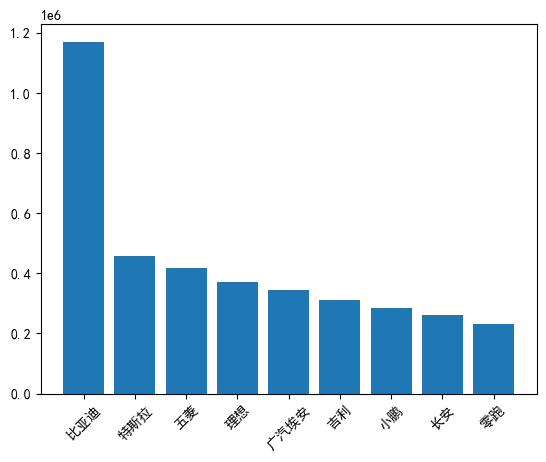

In [ ]:
plt.bar(df_agg['厂商'],df_agg['总销量'])
plt.xticks(rotation=45) #X 轴的文字说明旋转45度
plt.show()

In [13]:
# 统计每个厂商销售前3名的车型
df.show()

+----+----+----+--------+-----------+-----+-----------+
|年份|月份|排名|    厂商|       车型| 销量| 售价(万元)|
+----+----+----+--------+-----------+-----+-----------+
|2024|   1|   1|  比亚迪|宋PLUS DM-i|45210|15.98-21.98|
|2024|   1|   2|  比亚迪|       海豚|38760|10.28-13.68|
|2024|   1|   3|  特斯拉|    Model Y|32150|26.39-34.99|
|2024|   1|   4|    五菱| 宏光MINIEV|29800|  3.28-9.99|
|2024|   1|   5|    理想|         L7|25680|31.98-37.98|
|2024|   1|   6|广汽埃安|     AION Y|23120|11.98-18.98|
|2024|   1|   7|    吉利|     银河L7|20450|13.87-17.97|
|2024|   1|   8|    小鹏|         G6|18720|20.99-27.69|
|2024|   1|   9|    长安|   深蓝SL03|17340|14.59-19.19|
|2024|   1|  10|    零跑|        C11|15260|14.98-20.98|
|2024|   2|   1|  比亚迪|宋PLUS DM-i|42350|15.98-21.98|
|2024|   2|   2|  比亚迪|       海豚|36890|10.28-13.68|
|2024|   2|   3|  特斯拉|    Model Y|30120|26.39-34.99|
|2024|   2|   4|    五菱| 宏光MINIEV|27500|  3.28-9.99|
|2024|   2|   5|    理想|         L7|24100|31.98-37.98|
|2024|   2|   6|广汽埃安|     AION Y|21800|11.98-18.98|
|2024|  

In [18]:
df_agg=spark.sql(
    '''  
     with year_agg as (
     select `厂商`,
            `车型`,
            sum(`销量`) as `总销量`
        from ev_cars_sale
        group by `厂商`,`车型`
     ),
     rank_table as (
     select `厂商`,
            `车型`,
            `总销量`,
            rank() over(partition by `厂商` order by `总销量` desc) as rn
        from year_agg
     )
     select * from rank_table
     where rank_table.rn<=3
    '''
).toPandas()
df_agg.head(20)

,厂商,车型,总销量,rn
0,五菱,宏光MINIEV,416960,1
1,吉利,银河L7,310620,1
2,小鹏,G6,284050,1
3,广汽埃安,AION Y,345560,1
4,比亚迪,宋PLUS DM-i,631140,1
5,比亚迪,海豚,540260,2
6,特斯拉,Model Y,456870,1
7,理想,L7,372560,1
8,长安,深蓝SL03,262030,1
9,零跑,C11,232940,1


In [20]:
df_agg[df_agg['厂商']=='比亚迪']

,厂商,车型,总销量,rn
4,比亚迪,宋PLUS DM-i,631140,1
5,比亚迪,海豚,540260,2
